### step 1: import required libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [40]:
import string
import nltk
from nltk.corpus import stopwords
from wordcloud import WordCloud

In [55]:
from torch import nn

In [52]:
import torch
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split

ValueError: Existing Python class DType already has SerializedDType as its associated proto representation. Please ensure DType has a unique proto representation.

In [73]:
class TestModel(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, 64, 7, 1, 3)
        self.conv2 = nn.Conv2d(64, 128, 3, 1, 1)
        self.conv3 = nn.Conv2d(128, 256, 3, 1, 1)
        self.conv4 = nn.Conv2d(256, out_ch, 3, 1, 1)
        self.relu = nn.ReLU()
    
    def forward(self, x):
        x = self.relu(self.conv1(x))
        x = self.relu(self.conv2(x))
        x = self.relu(self.conv3(x))
        x = self.relu(self.conv4(x))        
        return x        

In [74]:
data = torch.rand(2,3,64,64)

In [75]:
model = TestModel(3, 10)

In [76]:
y = model(data)

In [77]:
y.shape

torch.Size([2, 10, 64, 64])

### step 2: load the dataset

In [21]:
data = pd.read_csv('./data/spam_ham_dataset.csv')

In [22]:
data.head()

,Unnamed: 0,label,text,label_num
0,605,ham,Subject: enron methanol ; meter # : 988291\r\n...,0
1,2349,ham,"Subject: hpl nom for january 9 , 2001\r\n( see...",0
2,3624,ham,"Subject: neon retreat\r\nho ho ho , we ' re ar...",0
3,4685,spam,"Subject: photoshop , windows , office . cheap ...",1
4,2030,ham,Subject: re : indian springs\r\nthis deal is t...,0


In [23]:
data.shape

(5171, 4)

<AxesSubplot:xlabel='label', ylabel='count'>

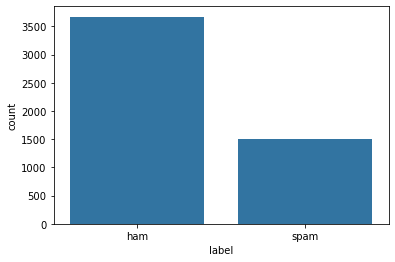

In [24]:
sns.countplot(x = 'label', data = data)  # 根据label特征计数

### step 3: balance the dataset

In [25]:
ham_msg = data[data['label'] == 'ham']
spam_msg = data[data['label'] == 'spam']

In [26]:
# Downsample Ham emails to match the number of Spam emails
ham_msg_balanced = ham_msg.sample(len(spam_msg), random_state=42)

In [27]:
# Combine balanced data
balanced_data = pd.concat([ham_msg_balanced, spam_msg]).reset_index(drop=True)

In [28]:
balanced_data.head()

,Unnamed: 0,label,text,label_num
0,3444,ham,Subject: conoco - big cowboy\r\ndarren :\r\ni ...,0
1,2982,ham,Subject: feb 01 prod : sale to teco gas proces...,0
2,2711,ham,Subject: california energy crisis\r\ncaliforni...,0
3,3116,ham,Subject: re : nom / actual volume for april 23...,0
4,1314,ham,Subject: eastrans nomination changes effective...,0


([<matplotlib.axis.XTick at 0x2063624e3d0>,
 [Text(0, 0, 'Ham (Not Spam)'), Text(1, 0, 'Spam')])

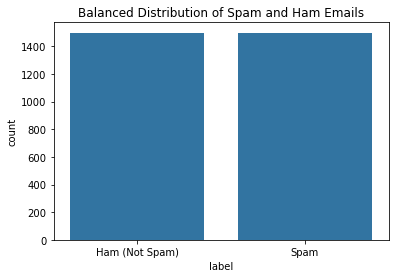

In [29]:
# Visualize the balanced dataset
sns.countplot(x='label', data=balanced_data)
plt.title("Balanced Distribution of Spam and Ham Emails")
plt.xticks(ticks=[0, 1], labels=['Ham (Not Spam)', 'Spam'])

### step 4: clean the text

In [30]:
balanced_data['text'] = balanced_data['text'].str.replace('Subject', '')

In [31]:
balanced_data.head()

,Unnamed: 0,label,text,label_num
0,3444,ham,: conoco - big cowboy\r\ndarren :\r\ni ' m not...,0
1,2982,ham,: feb 01 prod : sale to teco gas processing\r\...,0
2,2711,ham,": california energy crisis\r\ncalifornia  , s...",0
3,3116,ham,: re : nom / actual volume for april 23 rd\r\n...,0
4,1314,ham,: eastrans nomination changes effective 8 / 2 ...,0


#### punctuations removal

In [32]:
def remove_punctuations(text):
    temp = str.maketrans('', '', string.punctuation)
    return text.translate(temp)

In [33]:
balanced_data['text'] = balanced_data['text'].apply(remove_punctuations)

In [34]:
balanced_data.head()

,Unnamed: 0,label,text,label_num
0,3444,ham,conoco big cowboy\r\ndarren \r\ni m not sur...,0
1,2982,ham,feb 01 prod sale to teco gas processing\r\ns...,0
2,2711,ham,california energy crisis\r\ncalifornia  s p...,0
3,3116,ham,re nom actual volume for april 23 rd\r\nwe ...,0
4,1314,ham,eastrans nomination changes effective 8 2 0...,0


#### stopwords removal

In [35]:
def remove_stopwords(text):
    stop_words = stopwords.words('english')
    imp_words = list()
    
    for word in str(text).split():
        word = word.lower()
        
        if word not in stop_words:
            imp_words.append(word)
    
    output = ' '.join(imp_words)
    return output

In [36]:
balanced_data['text'] = balanced_data['text'].apply(remove_stopwords)

In [37]:
balanced_data.head()

,Unnamed: 0,label,text,label_num
0,3444,ham,conoco big cowboy darren sure help know else a...,0
1,2982,ham,feb 01 prod sale teco gas processing sale deal...,0
2,2711,ham,california energy crisis california  power cr...,0
3,3116,ham,nom actual volume april 23 rd agree eileen pon...,0
4,1314,ham,eastrans nomination changes effective 8 2 00 p...,0


### step 5: visualization word cloud

In [38]:
def plot_word_cloud(data, typ):
    email_corpus = " ".join(data['text'])
    wc = WordCloud(background_color='black', max_words=100, width=800, height=400).generate(email_corpus)
    plt.figure(figsize=(7, 7))
    plt.imshow(wc, interpolation='bilinear')
    plt.title(f'WordCloud for {typ} Emails', fontsize=15)
    plt.axis('off')

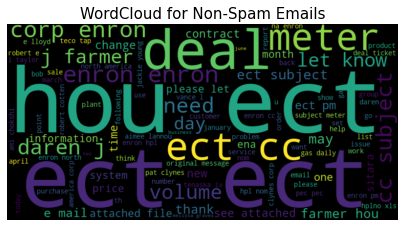

In [41]:
plot_word_cloud(balanced_data[balanced_data['label'] == 'ham'], typ='Non-Spam')

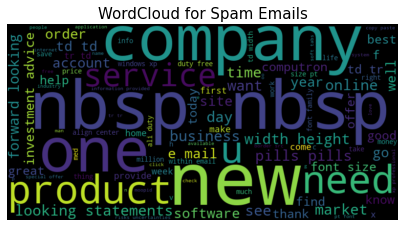

In [42]:
plot_word_cloud(balanced_data[balanced_data['label'] == 'spam'], typ='Spam')

### step 6: tokenization and padding

In [45]:
train_X, test_X, train_Y, test_Y = train_test_split(balanced_data['text'], balanced_data['label'], test_size=0.2, random_state=42)

In [ ]:
tokenizer = get_tokenizer()